In [120]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Root directory for all results
BASE_DIR = Path("./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000")


In [121]:
# main_result_path = {
#     "vanilla":
#     # [
#     #     "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
#     #     # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
#     #     "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
#     #     "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
#     # ],
#     [
#         "20260328-211058_MLP_FSNet_seed0_nepochs1000_lr0.0001_trainsize7000",
#         "20260328-211058_MLP_FSNet_seed3_nepochs1000_lr0.0001_trainsize7000",
#         "20260328-211058_MLP_FSNet_seed1_nepochs1000_lr0.0001_trainsize7000",
#         "20260328-211058_MLP_FSNet_seed2_nepochs1000_lr0.0001_trainsize7000",
#     ],
#     "pretraining":
#     [
#         "20260327-094852_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
#     ],
#     'epoch 50':
#     [
#         "20260327-104200_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
#         "20260327-095647_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
#         # "20260327-101148_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
#         "20260327-102658_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
#     ],  # 50
#     'epoch 100':
#     [
#         "20260117-185928_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
#         "20260117-185930_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
#         # "20260117-191324_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
#         "20260117-191337_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
#     ],  # 150
#     'epoch 250*':
#     [
#         "20260327-120154_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
#         # "20260327-121451_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
#         "20260327-123959_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
#         "20260327-122726_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
#     ],  # 150
#     'epoch 500':
#     [
# "20260327-115738_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
# "20260327-103029_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
# # "20260327-104759_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
# "20260327-112458_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
#     ],  # 250
#     'epoch 600':
#     [
# # "20260327-142657_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
# "20260327-142657_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
# "20260327-142700_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
# "20260327-142700_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
#     ],
# }

# # main_result_path = {
# #     "vanilla":
# #     [
# #         "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
# #         # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
# #         "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
# #         "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
# #     ],
# #     "pretraining":
# #     [
# #         "20260115-184954_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
# #     ],
# #     'ours':
# #     [
# # "20260118-060443_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# # # "20260118-055607_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# # "20260118-050530_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# # "20260118-050045_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990"
# #     ], # 3.0
# # }

In [185]:
main_result_path = {
    "vanilla":
    [
        "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
        "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
        "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
        "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    ],
    # [
    #     "20260328-211058_MLP_FSNet_seed0_nepochs1000_lr0.0001_trainsize7000",
    #     "20260328-211058_MLP_FSNet_seed3_nepochs1000_lr0.0001_trainsize7000",
    #     "20260328-211058_MLP_FSNet_seed1_nepochs1000_lr0.0001_trainsize7000",
    #     "20260328-211058_MLP_FSNet_seed2_nepochs1000_lr0.0001_trainsize7000",
    # ],
    "pretraining":
    [
        "20260327-094852_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
    ],
    'epoch 50':
    [
        "20260327-104200_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        "20260327-095647_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        "20260327-101148_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
        "20260327-102658_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_50",
    ],  # 50
    'epoch 100':
    [
        "20260327-130946_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-125737_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-131013_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
        "20260327-125738_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_100",
    ],
    'epoch 150':
    [
        "20260117-185928_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-185930_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191324_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191337_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
    ],  # 150
    'epoch 250*':
    # [
    #     "20260327-120154_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
    #     "20260327-121451_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
    #     "20260327-123959_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
    #     "20260327-122726_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
    # ], 
    [
        "20260505-203425_MLP_FSNet_seed0_nepochs200_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
        "20260505-204646_MLP_FSNet_seed1_nepochs200_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_250",
    ],
    'epoch 300':
    [
        "20260327-115518_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
        "20260327-115905_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
        "20260327-114457_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
        "20260327-114042_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_300",
    ],
    'epoch 350':
    [
        "20260505-200124_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_350",
        "20260505-193626_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_350",
        "20260505-193617_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_350",
        "20260505-200318_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_350",
    ],
    'epoch 400':
    [
        "20260505-194946_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_400", 
        "20260505-194854_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_400",
        "20260505-201650_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_400",
        "20260505-201351_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_400",
    ],
    'epoch 450':
    [
        "20260505-093744_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_450",
        "20260505-100039_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_450",
        # "20260505-092612_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_450",
        "20260505-094914_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_450",
    ],
    'epoch 500':
    [
        "20260327-115738_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-103029_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-104759_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
        "20260327-112458_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_500",
    ],  # 250
    'epoch 550':
    [
        "20260505-140412_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_550",
        "20260505-164331_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_550",
        "20260505-164402_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_550",
        "20260505-164533_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_550"

    ],
    'epoch 600':
    [
        "20260327-142657_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
        "20260327-142657_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
        "20260327-142700_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
        "20260327-142700_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_600",
    ],
    'epoch 650':
    [
        # "20260505-165617_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_650",
        "20260505-141713_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_650",
        # "20260505-165807_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_650",
        "20260505-165715_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_650",
    ],
    'epoch 700':
    [
        "20260327-134723_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",
        "20260327-140003_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",
        "20260327-140018_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",
        "20260327-134723_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_700",
    ],
    'epoch 750':
    [
        "20260505-171107_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_750",
        "20260505-170900_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_750",
        "20260505-143021_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_750",
        "20260505-171057_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_750",
    ],
    'epoch 800':
    [
        "20260327-123724_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
        "20260327-122356_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
        "20260327-120956_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
        "20260327-125045_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_800",
    ],
    'epoch 850':
    [
        "20260505-172258_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_850",
        "20260505-172325_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_850",
        "20260505-144346_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_850",
        "20260505-172000_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_850",
    ],
    'epoch 900':
    [
        "20260327-144644_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
        "20260327-145831_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
        "20260327-145904_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
        "20260327-144644_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_900",
    ],
    'epoch 950':
    [
        "20260505-173530_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_950",
        "20260505-173151_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_950",
        "20260505-145630_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_950",
        "20260505-173602_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260327-094852_sup_seedpen_model_950",
    ],
}

# main_result_path = {
#     "vanilla":
#     [
#         "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
#         # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
#         "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
#         "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
#     ],
#     "pretraining":
#     [
#         "20260115-184954_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0",
#     ],
#     'ours':
#     [
# "20260118-060443_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# # "20260118-055607_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# "20260118-050530_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990",
# "20260118-050045_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184954_sup_seedpen_model_990"
#     ], # 3.0
# }

In [200]:
# --- Functions ---
def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_metrics(results, history_key='val_history'):
    if history_key not in results or not results[history_key]:
        return None
    metrics = {k: [] for k in results[history_key][0].keys()}
    for entry in results[history_key]:
        for key in metrics.keys():
            metrics[key].append(entry[key])
    return {k: np.array(v) for k, v in metrics.items()}

def load_and_recompute(result_paths, base_path):
    data_tree = {}
    for method, folders in result_paths.items():
        data_tree[method] = []
        for folder in folders:
            p = base_path / folder / "results.pkl"
            if p.exists():
                res = load_results(p)
                m = get_metrics(res, 'val_history')
                eq_weight = 1e5
                ineq_weight = 1e5   
                
                # Recompute Merit Mean using requested keys
                m['recomputed_merit_mean'] = (
                    m['objective'] + 
                    eq_weight * m['eq_violation_l1_mean'] + ineq_weight * m['ineq_violation_l1_mean']
                )
                
                m['recomputed_merit_max'] = (
                    m['objective_max'] + 
                    eq_weight * m['eq_violation_l1_max'] + ineq_weight * m['ineq_violation_l1_max']
                )
                
                # m['recomputed_merit_mean'] = (
                #     m['merit_mean']
                # )
                
                # m['recomputed_merit_max'] = (
                #     m['merit_max']
                # )
                data_tree[method].append(m)
            else:
                print(f"Warning: Path not found {p}")
    return data_tree

In [187]:
processed_data = load_and_recompute(main_result_path, BASE_DIR)

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter

FONT_SIZE = 24
LINE_WIDTH = 3

# Use two palettes:
# - FILL_COLORS: light (for bands)
# - LINE_COLORS: darker (for strokes, markers, annotation)
FILL_COLORS = {
    "vanilla": "#F2B8A2",      # light peach
    "pretraining": "#086EB6",#"#000000",  # light steel-blue
    "epoch 50": "#AFAFAF",         # light teal-green
    "epoch 100": "#AFAFAF",         # light teal-green
    "epoch 250*": "#BFE5D3",         # light teal-green
    "epoch 500": "#AFAFAF",         # light teal-green
    "epoch 600": "#AFAFAF",         # light teal-green
}
LINE_COLORS = {
    "vanilla": "#C97D77",     # muted brick red
    "pretraining": "#086EB6", # steel blue
    "epoch 50": "#818181",        # sage green (updated)
    "epoch 250*": "#6E8F71",        # sage green (updated)
    "epoch 100": "#818181",        # sage green (updated)
    "epoch 500": "#818181",        # sage green (updated)
    "epoch 600": "#818181",        # sage green (updated)
}
STYLES = {"vanilla": "-", "pretraining": "-", "epoch 50": "--", "epoch 100": "--", "epoch 250*": "-", "epoch 500": "--", "epoch 600": "--"}  # keep your original

def get_val_metrics(results):
    metrics = get_metrics(results, 'val_history')
    return metrics

def get_train_metrics(results):
    metrics = get_metrics(results, 'train_history')
    if metrics is None:
        return None
    return metrics

def style_main_axis(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(LINE_WIDTH*0.75)
        spine.set_color('black')
    ax.spines['top'].set_visible(True)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', labelsize=FONT_SIZE, width=LINE_WIDTH, color='black')

def plot_pretraining_learning(result_paths, base_path):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax_left = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    pretrain_folder = result_paths['pretraining'][0]
    pretrain_results = load_results(base_path / pretrain_folder / 'results.pkl')
    val_metrics = get_val_metrics(pretrain_results)
    train_metrics = get_train_metrics(pretrain_results)

    x_val = np.array([entry['epoch'] for entry in pretrain_results['val_history']])
    x_train = np.array([entry['epoch'] for entry in pretrain_results['train_history']])

    merit_color = LINE_COLORS['pretraining']
    loss_color = LINE_COLORS['vanilla']

    ax_left.set_xlabel('# SL epochs', fontsize=FONT_SIZE)
    ax_left.set_ylabel('merit', color=merit_color, fontsize=FONT_SIZE)
    ax_left.plot(
        x_val[2:],
        val_metrics['objective'][2:] + 1e5 * val_metrics['eq_violation_l1_mean'][2:] + 1e5 * val_metrics['ineq_violation_l1_mean'][2:],
        color=merit_color,
        linewidth=LINE_WIDTH*1.5,
        linestyle='-',
    )
    left_merit = val_metrics['objective'] + 1e5 * val_metrics['eq_violation_l1_mean'] + 1e5 * val_metrics['ineq_violation_l1_mean']
    left_markers = [5, 10, 50, 60]
    for marker in left_markers:
        ax_left.plot(
            marker * 10,
            left_merit[marker],
            color=merit_color,
            linewidth=LINE_WIDTH*1.5,
            marker='d',
            markersize=LINE_WIDTH * 7,
            markeredgewidth=LINE_WIDTH - 2,
            markeredgecolor='white',
        )
    ax_left.plot(
        250,
        left_merit[25],
        color=merit_color,
        linewidth=LINE_WIDTH*1.5,
        marker='*',
        markersize=LINE_WIDTH * 11,
        markeredgewidth=LINE_WIDTH - 2,
        markeredgecolor='white',
    )
    ax_left.tick_params(axis='y', labelcolor=merit_color, width=LINE_WIDTH)
    ax_left.locator_params(axis='y', nbins=4)
    ax_left.set_xticks([0, 250, 500, 750, 1000])



    ax_left.set_title('supervised pretraining', fontsize=FONT_SIZE*1.1, pad=10)
    style_main_axis(ax_left)

    ax_left_right = ax_left.twinx()
    ax_left_right.set_ylabel('loss', color=loss_color, fontsize=FONT_SIZE)
    ax_left_right.plot(
        x_train[2:],
        train_metrics['loss'][2:],
        color=loss_color,
        linewidth=LINE_WIDTH*1.5,
        linestyle='--',
    )
    ax_left_right.tick_params(axis='y', labelcolor=loss_color, width=LINE_WIDTH, labelsize=FONT_SIZE)
    ax_left_right.spines['top'].set_visible(True)
    ax_left_right.set_yscale('log')
    ax_left.set_zorder(ax_left_right.get_zorder() + 1)
    ax_left.patch.set_visible(False)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((5, 5))
    ax_left.yaxis.set_major_formatter(formatter)
    ax_left.yaxis.get_offset_text().set_fontsize(FONT_SIZE * 0.7)
    ax_left.yaxis.get_offset_text().set_position((-0.15, -1.0))
    fig.patch.set_facecolor('white')
    plt.show()

def plot_ssl_learning(data_tree, metric_name='recomputed_merit_mean'):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax_right = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    methods_to_plot = {
        'from SL 50': 'epoch 50',
        'from SL 100': 'epoch 100',
        'from SL 500': 'epoch 500',
        'from SL 600': 'epoch 600',
        'from SL 250*': 'epoch 250*',
        'vanilla': 'vanilla',
    }
    OURS_XLIM = 22
    for label, key in methods_to_plot.items():
        if key in data_tree and data_tree[key]:
            runs = data_tree[key]
            epochs = np.array(runs[0]['epoch']) + 5
            print(len(epochs))

            vals = np.mean([np.array(run[metric_name]) for run in runs], axis=0)
            if key == 'epoch 250*':
                ax_right.plot(
                    epochs[:OURS_XLIM],
                    vals[:OURS_XLIM],
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=LINE_WIDTH*1.5,
                    alpha=1.0,
                    marker='*',
                    markersize=LINE_WIDTH * 9,
                    markeredgewidth=LINE_WIDTH - 2,
                    markeredgecolor='white',
                    markevery=5,
                )
            else:
                ax_right.plot(
                    epochs,
                    vals,
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=LINE_WIDTH*1.5,
                    alpha=1.0 if key in ['vanilla'] else 0.4,
                )
            if len(runs) > 1:
                if key == 'epoch 250*':
                    std = np.std([np.array(run[metric_name]) for run in runs], axis=0)
                    ax_right.fill_between(
                        epochs[:OURS_XLIM],
                        vals[:OURS_XLIM] - std[:OURS_XLIM],
                        vals[:OURS_XLIM] + std[:OURS_XLIM],
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )
                else:
                    std = np.std([np.array(run[metric_name]) for run in runs], axis=0)
                    ax_right.fill_between(
                        epochs,
                        vals - std,
                        vals + std,
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )

    ax_right.set_xlabel('# SSL epochs', fontsize=FONT_SIZE)
    ax_right.set_ylabel('merit', fontsize=FONT_SIZE)
    ax_right.tick_params(axis='y', width=LINE_WIDTH)
    # apply_merit_formatter(ax_right)
    ax_right.set_title('self-supervised learning', fontsize=FONT_SIZE*1.1, pad=10)
    ax_right.set_xlim(0, 500)
    ax_right.set_ylim(-5, 30)
    ax_right.locator_params(axis='y', nbins=4)
    ax_right.legend(frameon=True, loc='upper right', fontsize=FONT_SIZE - 4)
    style_main_axis(ax_right)

    fig.patch.set_facecolor('white')
    plt.show()


def plot_sl_to_ssl_merit_transfer(result_paths, base_path, data_tree, metric_name='recomputed_merit_mean', checkpoints=None):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    pretrain_folder = result_paths['pretraining'][0]
    pretrain_results = load_results(base_path / pretrain_folder / 'results.pkl')
    val_metrics = get_val_metrics(pretrain_results)
    x_val = np.array([entry['epoch'] for entry in pretrain_results['val_history']])
    sl_merit = (
        val_metrics['objective']
        + 1e5 * val_metrics['eq_violation_l1_mean']
        + 1e5 * val_metrics['ineq_violation_l1_mean']
    )

    if checkpoints is None:
        checkpoints = [
            ('SL 50', 'epoch 50', 50),
            ('SL 150', 'epoch 150', 150),
            ('SL 250*', 'epoch 250*', 250),
            # ('SL 500', 'epoch 500', 500),
            ('SL 600', 'epoch 600', 600),
            ('SL 150', 'epoch 150', 150),
            ('SL 550', 'epoch 550', 550),
            ('SL 650', 'epoch 650', 650),
            # ('SL 750', 'epoch 750', 750),
            # ('SL 850', 'epoch 850', 850),
            # ('SL 950', 'epoch 950', 950),
        ]

    xs, ys, yerrs, labels = [], [], [], []
    for label, key, sl_epoch in checkpoints:
        if key not in data_tree or not data_tree[key]:
            continue
        sl_idx = int(np.argmin(np.abs(x_val - sl_epoch)))
        ssl_runs = [np.array(run[metric_name]) for run in data_tree[key]]
        ssl_best_by_run = np.array([np.min(run) for run in ssl_runs])

        xs.append(sl_merit[sl_idx])
        ys.append(np.mean(ssl_best_by_run))
        yerrs.append(np.std(ssl_best_by_run))
        labels.append(label)

    xs = np.array(xs)
    ys = np.array(ys)
    yerrs = np.array(yerrs)
    ax.errorbar(
        xs,
        ys,
        yerr=yerrs,
        fmt='o',
        markersize=14,
        color='#6E8F71',
        ecolor='#6E8F71',
        elinewidth=LINE_WIDTH,
        capsize=6,
        capthick=LINE_WIDTH,
        markeredgecolor='white',
        markeredgewidth=LINE_WIDTH - 1,
        zorder=3,
    )
    for x, y, label in zip(xs, ys, labels):
        ax.annotate(label, (x, y), xytext=(8, 8), textcoords='offset points', fontsize=FONT_SIZE - 8)

    if len(xs) > 1:
        order = np.argsort(xs)
        ax.plot(xs[order], ys[order], color='#6E8F71', linewidth=LINE_WIDTH, alpha=0.65)
        r = np.corrcoef(xs, ys)[0, 1]
        ax.text(0.04, 0.94, f'r = {r:.2f}', transform=ax.transAxes, fontsize=FONT_SIZE - 4, va='top')

    ax.set_xlabel('SL merit loss', fontsize=FONT_SIZE)
    ax.set_ylabel('SSL merit loss', fontsize=FONT_SIZE)
    ax.set_ylim(-2, 3)
    # ax.set_title('SL merit vs. SSL merit', fontsize=FONT_SIZE*1.1, pad=10)
    ax.locator_params(axis='both', nbins=4)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x / 1e5:g}'))
    ax.text(1.0, -0.01, '1e5', transform=ax.transAxes, ha='right', va='top', fontsize=FONT_SIZE - 4)
    style_main_axis(ax)
    fig.patch.set_facecolor('white')
    plt.show()


def plot_sl_train_loss_to_ssl_merit_transfer(result_paths, base_path, data_tree, metric_name='recomputed_merit_mean', checkpoints=None):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True, dpi=300)

    pretrain_folder = result_paths['pretraining'][0]
    pretrain_results = load_results(base_path / pretrain_folder / 'results.pkl')
    train_metrics = get_train_metrics(pretrain_results)
    x_train = np.array([entry['epoch'] for entry in pretrain_results['train_history']])

    if checkpoints is None:
        checkpoints = [
            ('SL 50', 'epoch 50', 50),
            ('SL 150', 'epoch 150', 150),
            ('SL 250*', 'epoch 250*', 250),
            # ('SL 500', 'epoch 500', 500),
            ('SL 600', 'epoch 600', 600),
            ('SL 150', 'epoch 150', 150),
            ('SL 550', 'epoch 550', 550),
            ('SL 650', 'epoch 650', 650),
            # ('SL 750', 'epoch 750', 750),
            # ('SL 850', 'epoch 850', 850),
            # ('SL 950', 'epoch 950', 950),
        ]

    xs, ys, yerrs, labels = [], [], [], []
    for label, key, sl_epoch in checkpoints:
        if key not in data_tree or not data_tree[key]:
            continue
        sl_idx = int(np.argmin(np.abs(x_train - sl_epoch)))
        ssl_runs = [np.array(run[metric_name]) for run in data_tree[key]]
        ssl_best_by_run = np.array([np.min(run) for run in ssl_runs])

        xs.append(train_metrics['loss'][sl_idx])
        ys.append(np.mean(ssl_best_by_run))
        yerrs.append(np.std(ssl_best_by_run))
        labels.append(label)

    xs = np.array(xs)
    ys = np.array(ys)
    yerrs = np.array(yerrs)
    ax.errorbar(
        xs,
        ys,
        yerr=yerrs,
        fmt='o',
        markersize=14,
        color='#C97D77',
        ecolor='#C97D77',
        elinewidth=LINE_WIDTH,
        capsize=6,
        capthick=LINE_WIDTH,
        markeredgecolor='white',
        markeredgewidth=LINE_WIDTH - 1,
        zorder=3,
    )
    for x, y, label in zip(xs, ys, labels):
        ax.annotate(label, (x, y), xytext=(8, 8), textcoords='offset points', fontsize=FONT_SIZE - 8)

    if len(xs) > 1:
        order = np.argsort(xs)
        ax.plot(xs[order], ys[order], color='#C97D77', linewidth=LINE_WIDTH, alpha=0.65)
        r = np.corrcoef(xs, ys)[0, 1]
        ax.text(0.04, 0.94, f'r = {r:.2f}', transform=ax.transAxes, fontsize=FONT_SIZE - 4, va='top')

    ax.set_xlabel('SL training loss', fontsize=FONT_SIZE)
    ax.set_ylabel('SSL merit loss', fontsize=FONT_SIZE)
    ax.set_ylim(-2, 3)
    ax.locator_params(axis='both', nbins=4)
    style_main_axis(ax)
    fig.patch.set_facecolor('white')
    plt.show()


if __name__ == "__main__":
    # Example usage:
    # plot_learning_1x2(data_tree, main_result_path, BASE_DIR, metric_name='recomputed_merit_mean')
    # plot_pretraining_learning(main_result_path, BASE_DIR)
    # plot_ssl_learning(processed_data, metric_name='recomputed_merit_mean')
    pass


In [189]:
# plot_learning_1x2(processed_data, main_result_path, BASE_DIR)

In [190]:
# plot_pretraining_learning(main_result_path, BASE_DIR)
# plot_ssl_learning(processed_data, metric_name='recomputed_merit_mean')
# plot_sl_to_ssl_merit_transfer(main_result_path, BASE_DIR, processed_data, metric_name='recomputed_merit_mean')

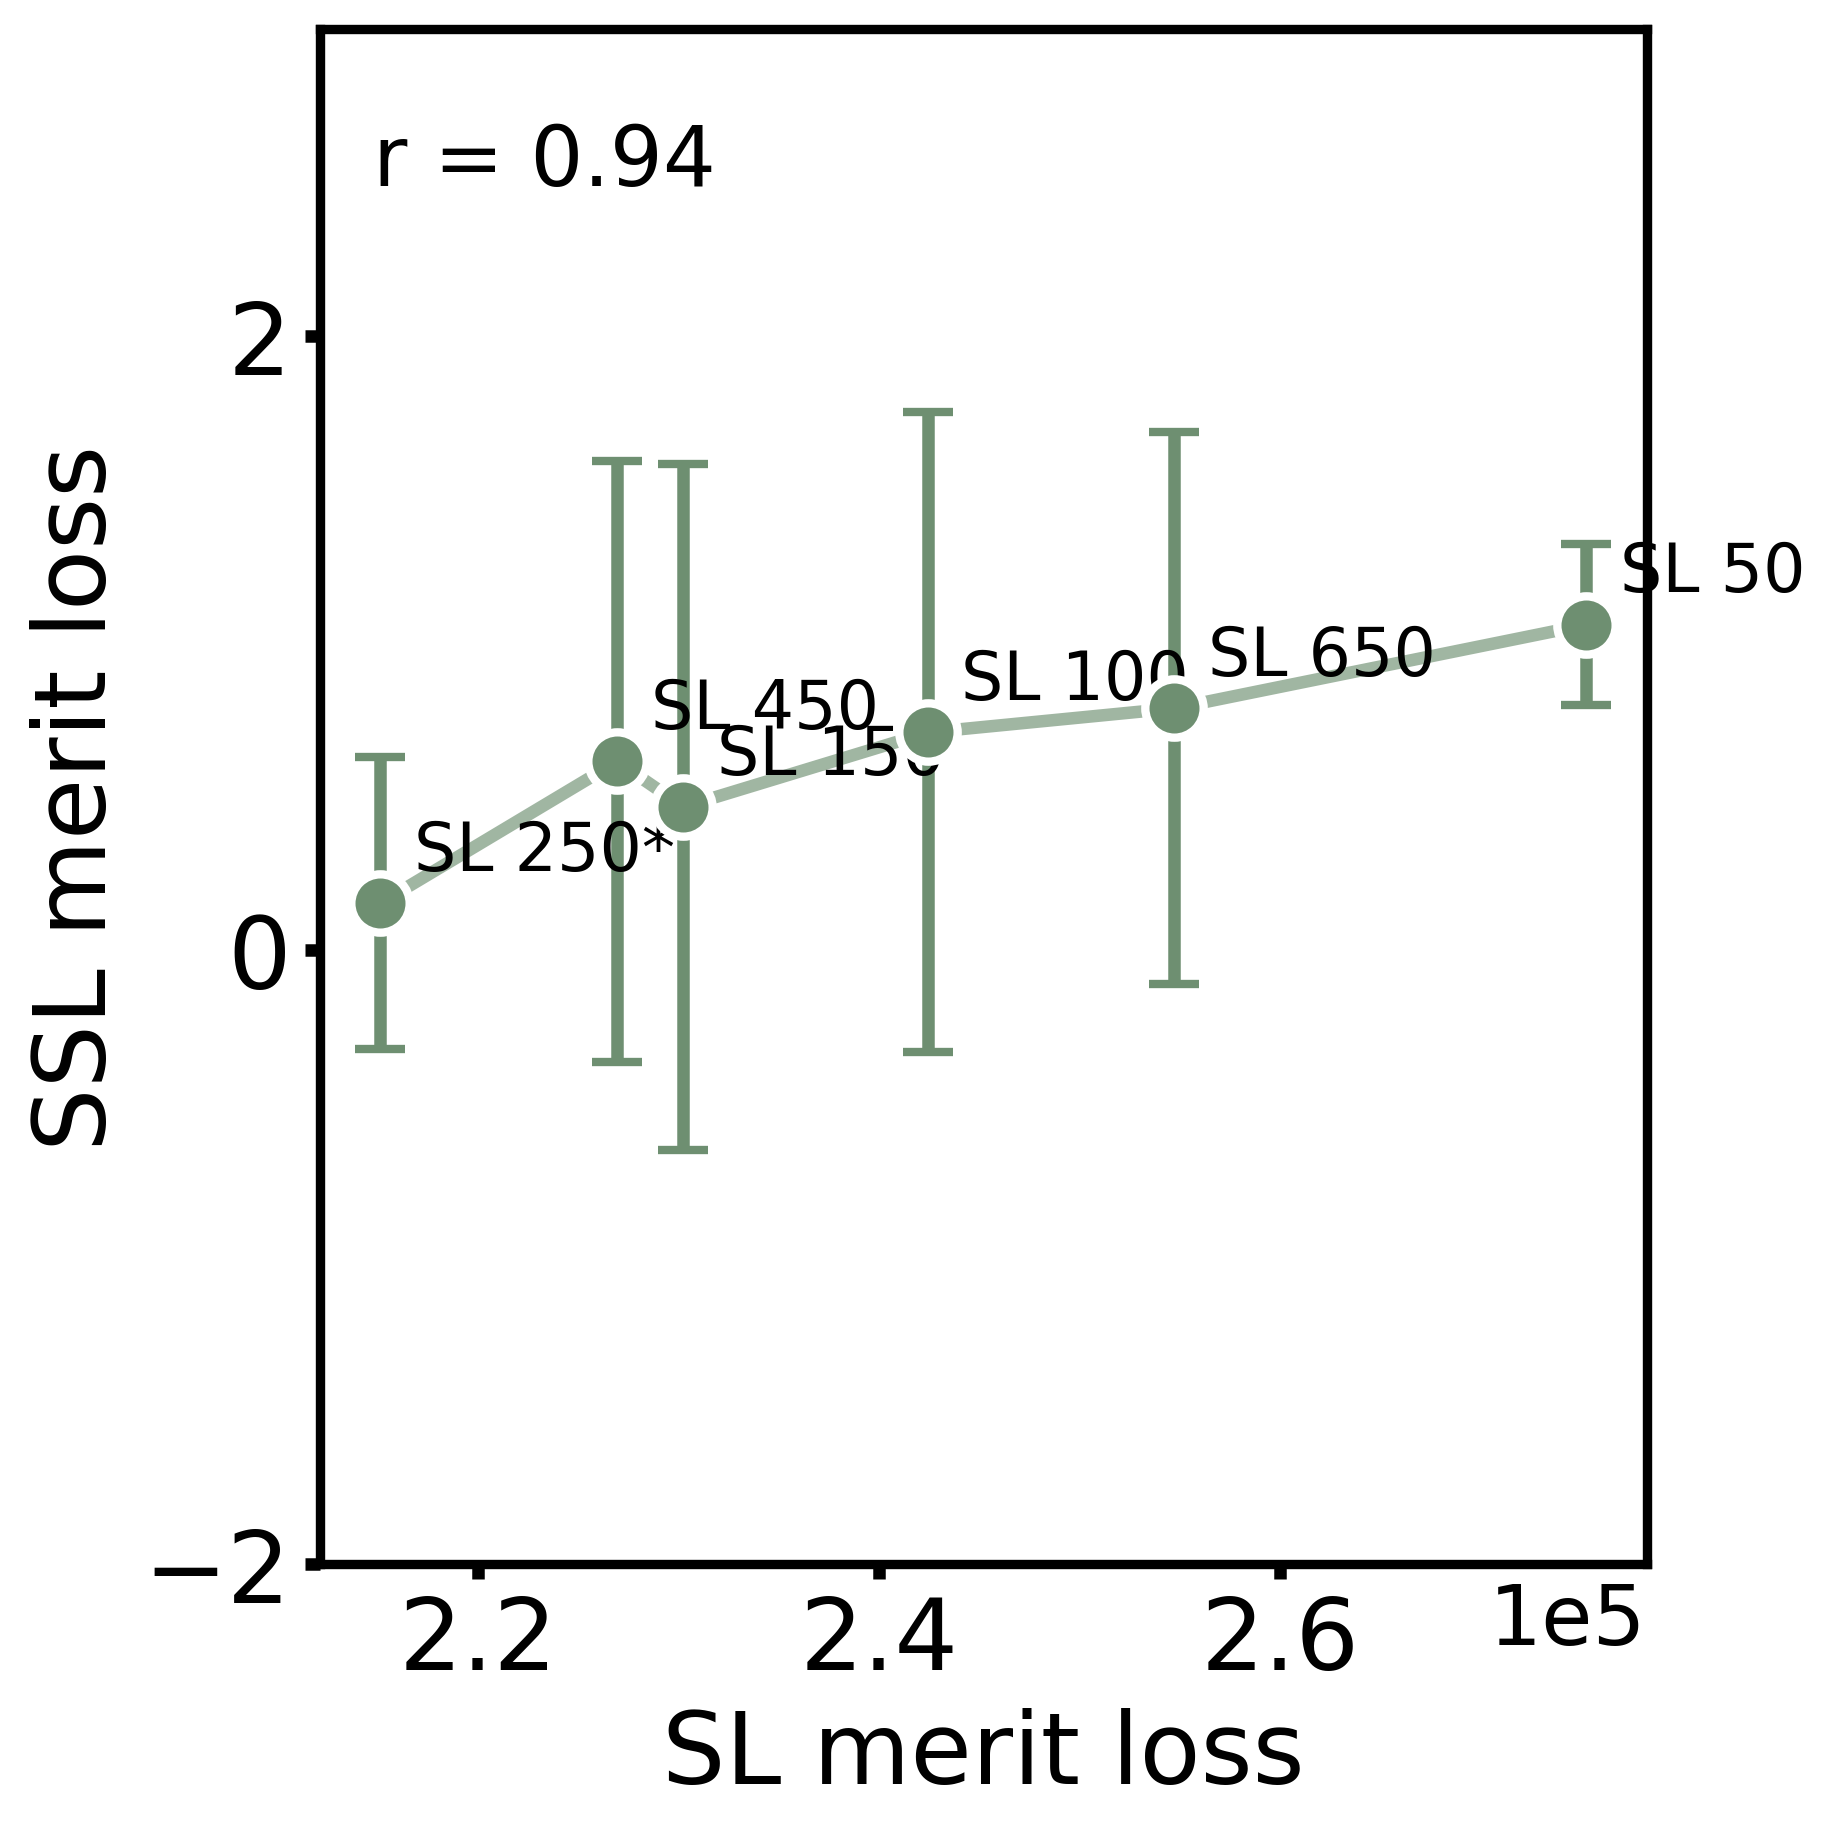

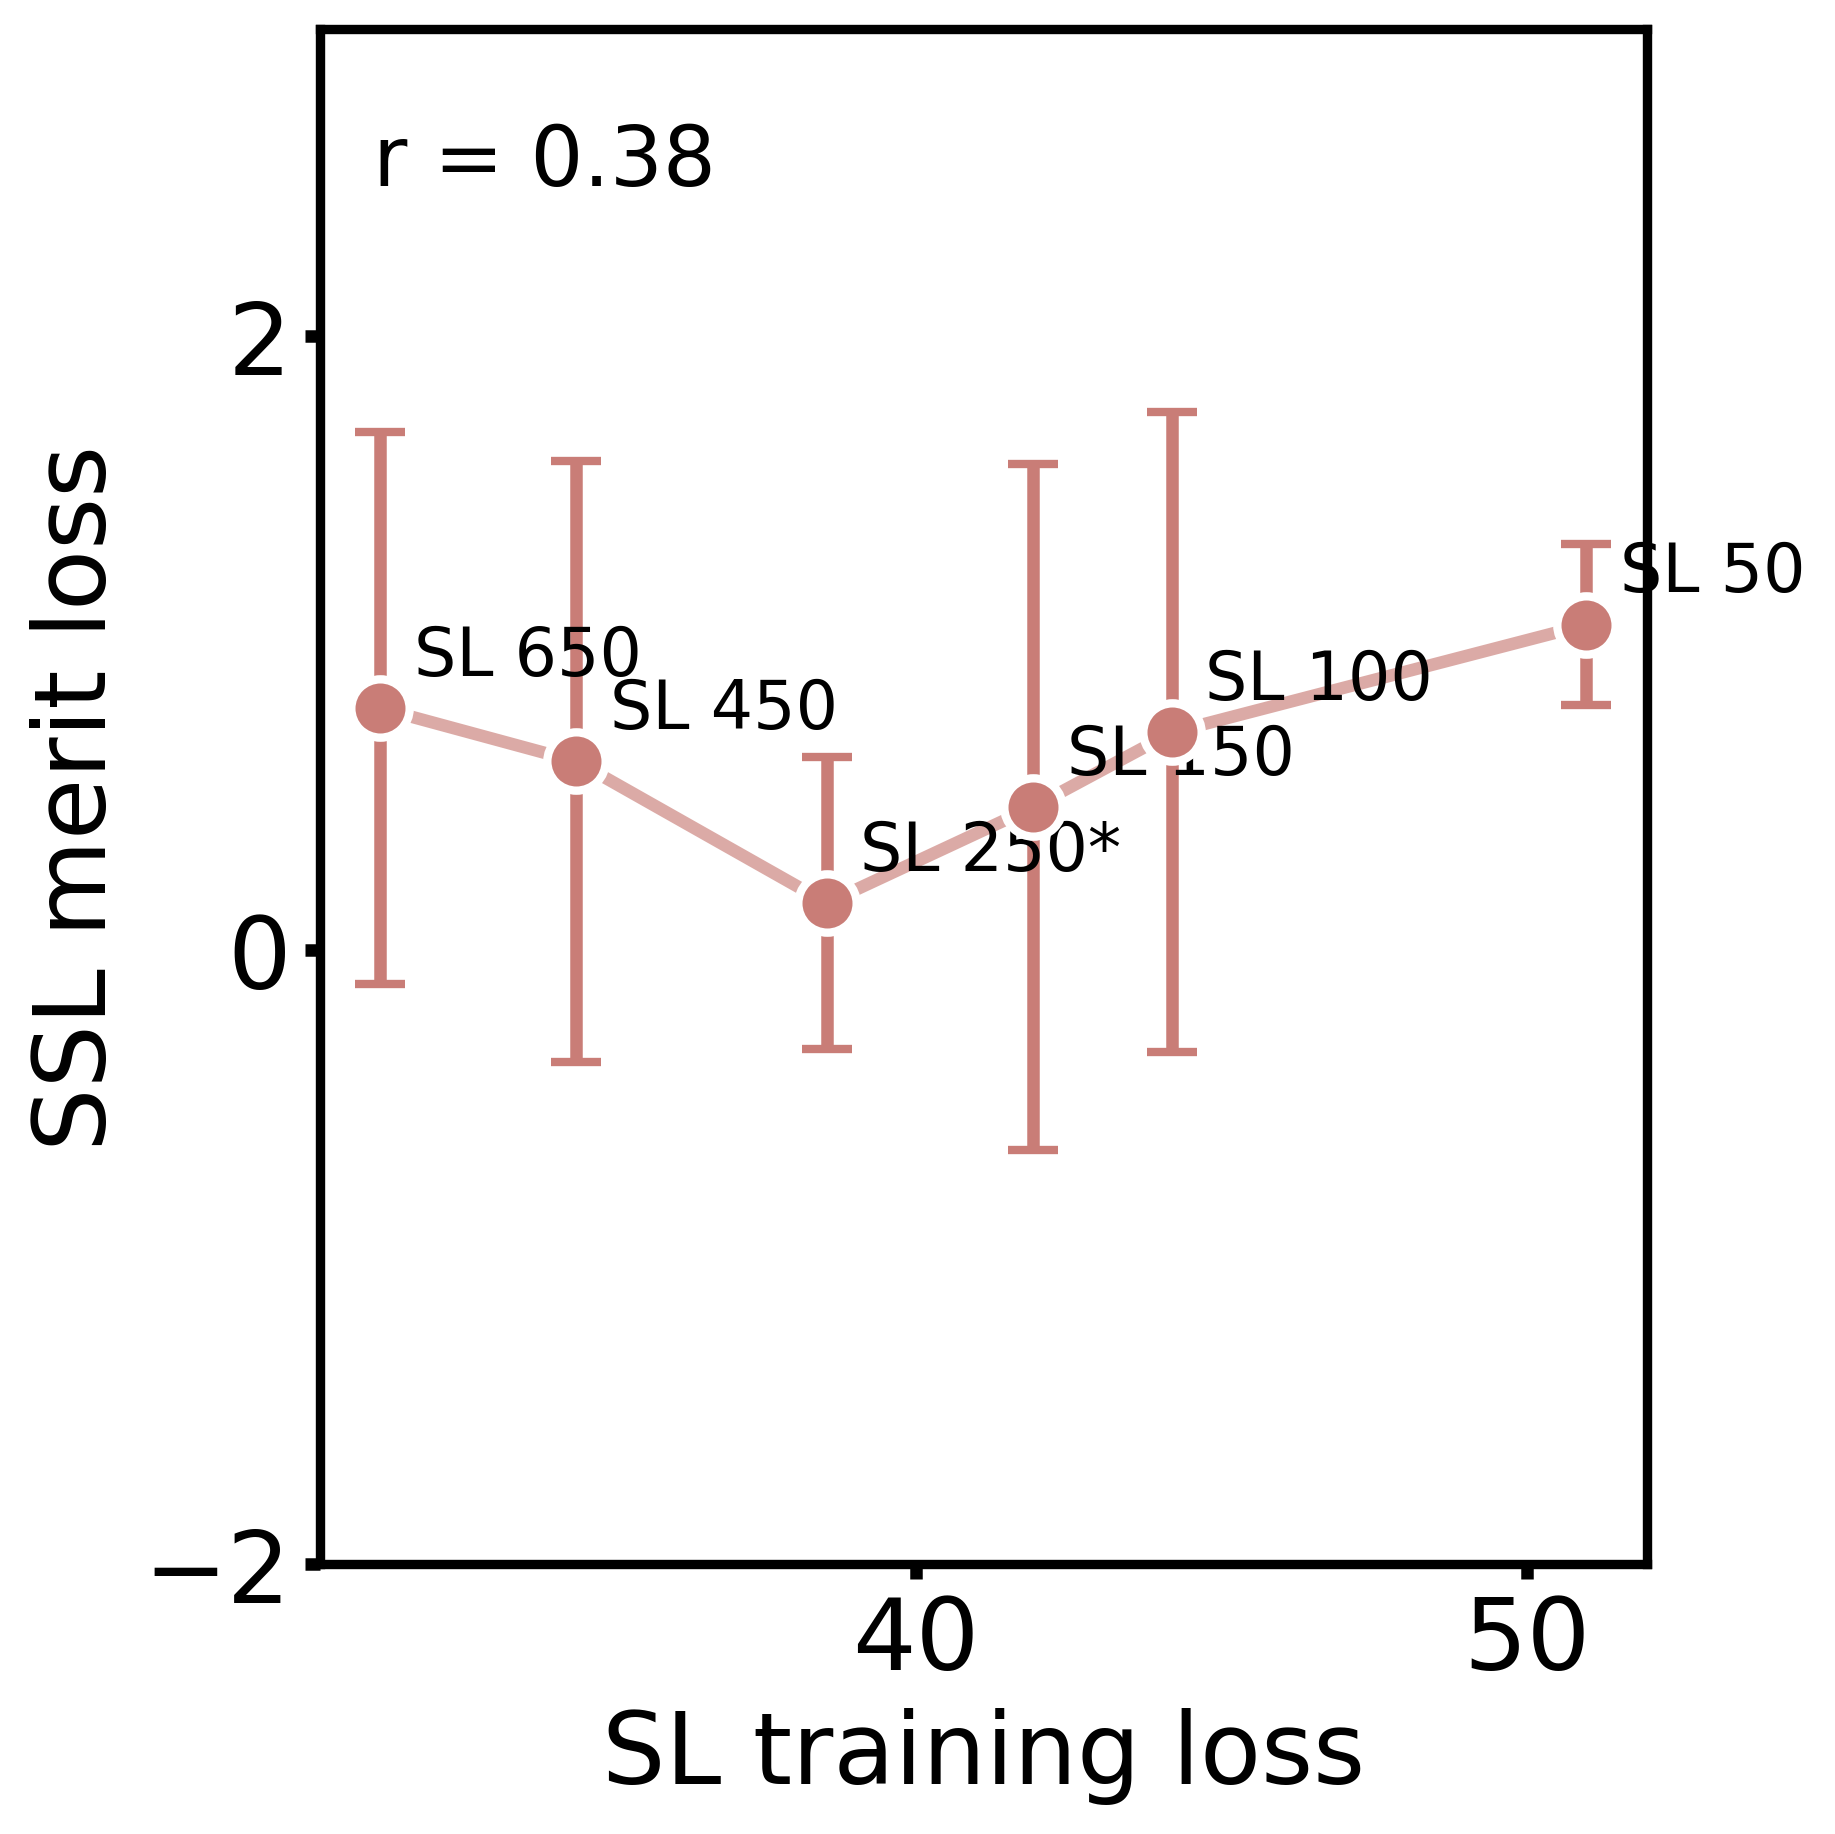

In [199]:
checkpoints = [
    ('SL 50', 'epoch 50', 50),
    ('SL 100', 'epoch 100', 100),
    ('SL 150', 'epoch 150', 150),
    # ('SL 200', 'epoch 200', 200),
    ('SL 250*', 'epoch 250*', 250),
    # ('SL 300', 'epoch 300', 300),
    # ('SL 350', 'epoch 350', 350),
    # ('SL 400', 'epoch 400', 400),
    ('SL 450', 'epoch 450', 450),
    # ('SL 500', 'epoch 500', 500),
    # ('SL 550', 'epoch 550', 550),
    # ('SL 600', 'epoch 600', 600),
    ('SL 650', 'epoch 650', 650),
    # ('SL 700', 'epoch 700', 700),
    # ('SL 750', 'epoch 750', 750),
    # ('SL 800', 'epoch 800', 800),
    # ('SL 850', 'epoch 850', 850),
    # ('SL 900', 'epoch 900', 900),
    # ('SL 950', 'epoch 950', 950),
]

plot_sl_to_ssl_merit_transfer(
    main_result_path,
    BASE_DIR,
    processed_data,
    metric_name='recomputed_merit_mean',
    checkpoints=checkpoints,
)
plot_sl_train_loss_to_ssl_merit_transfer(
    main_result_path,
    BASE_DIR,
    processed_data,
    metric_name='recomputed_merit_mean',
    checkpoints=checkpoints,
)
